In [1]:
import pandas as pd
import seaborn as sns

In [2]:
insurance_data = pd.read_csv("insurance.csv")

In [3]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

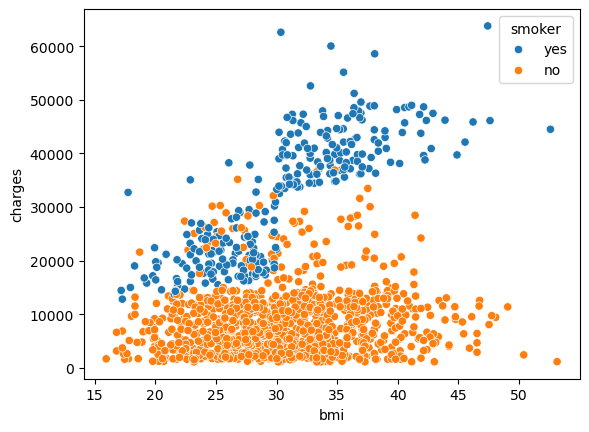

In [4]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["smoker"])

In [5]:
x = insurance_data.drop(columns=["charges", "region"]) #input
y = insurance_data["charges"] # output

# feature engineering
x["sex"] = x["sex"].map({"female":0, "male": 1})
x["smoker"] = x["smoker"].map({"no":0, "yes": 1})

In [6]:
x.head()

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0


In [7]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [8]:
# Train Test Split (80% of data to train, 20% of data to test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42) # store them in 33(test) and 67 (train)



In [9]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,0,25.175,2,0
887,36,0,30.020,0,0
890,64,0,26.885,0,1
1293,46,1,25.745,3,0
259,19,1,31.920,0,1


In [10]:
# Train Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# model predict
y_pred = model.predict(X_test)

In [12]:
y_pred

array([ 8405.9256603 ,  6896.23868525, 36895.58982383,  9381.50792191,
       26906.1365246 , 11167.26691409,   -52.69388791, 17003.5884751 ,
         575.64200873, 11145.24343373, 28431.0500438 ,  9298.88891839,
        5294.83953877, 38581.62045961, 40647.29738538, 37335.41236692,
       15260.70329561, 36045.12604011,  9244.08043852, 31386.21778584,
        4015.58602553, 10490.18916689,  2708.82651796,  6468.42991083,
       11072.02704479, 12500.72229041, 14877.39949351,  5794.09409262,
        9403.21599957,  2360.24884221,  9217.51655148, 13004.22249444,
        4569.43116562,  3115.50014448,  4790.29128958, 12649.03618987,
        2138.09676654,  9070.5629006 , 33211.37040636, 32831.55019384,
        3853.65967798,  4188.60226701, 14437.80767895, 11564.56259495,
        8911.3474146 , 12618.77374452,  4913.52403387,  3246.38268389,
       35678.69855772,  9262.17721379, 16062.42168636,  2482.54914576,
       12104.01258015,  1028.71074727, 13752.32805479, 12164.14248636,
      

In [13]:
y_test 

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
644     18806.14547
602     11070.53500
731     10065.41300
321     24671.66334
479      1824.28540
Name: charges, Length: 442, dtype: float64

In [14]:
# Evaluate 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared: ", r2)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("adjusted r2: ", adjusted_r2)

r-squared:  0.7587422388407032
adjusted r2:  0.7559755213962159


In [15]:
X_test.shape

(442, 5)

In [16]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
# One hot encoding
X = insurance_data.drop(columns=["charges"]) #input
y = insurance_data["charges"] # output

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int) # generates the category into columns and 
# if we do the drop_first = True; then the first category col will drop means if all the other categ(other than 
# which we drop) is 0, then it will compute that the the it is catg which we drop is set to 1

# feature engineering
X["sex"] = X["sex"].map({"female":0, "male": 1})
X["smoker"] = X["smoker"].map({"no":0, "yes": 1})

In [18]:
X.head(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0
5,31,0,25.740,0,0,0,1,0
6,46,0,33.440,1,0,0,1,0
7,37,0,27.740,3,0,1,0,0
8,37,1,29.830,2,0,0,0,0
9,60,0,25.840,0,0,1,0,0


In [19]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r-squared: ", r2)

# n = X_test.shape[0]
# p = X_test.shape[1]
# adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

# print("adjusted r2: ", adjusted_r2)

r-squared:  0.7605492639270065


In [20]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r-squared: ", r2)

# n = X_test.shape[0]
# p = X_test.shape[1]
# adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

# print("adjusted r2: ", adjusted_r2)

r-squared:  0.7605492639270065


In [21]:
# interaction features
X = insurance_data.drop(columns=["charges"]) #input
y = insurance_data["charges"] # output

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int) 

X["sex"] = X["sex"].map({"female":0, "male": 1})
X["smoker"] = X["smoker"].map({"no":0, "yes": 1})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

<Axes: xlabel='age', ylabel='charges'>

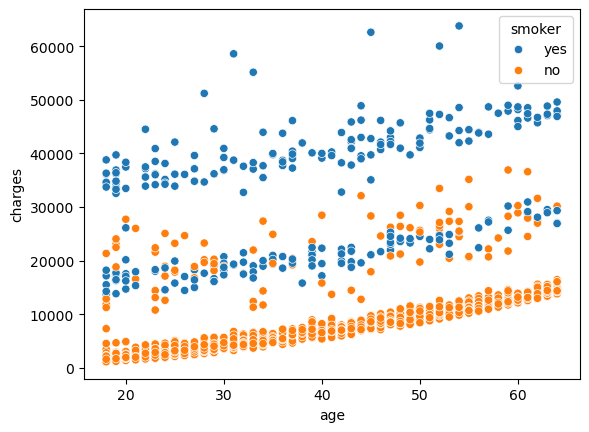

In [22]:
sns.scatterplot(x=insurance_data["age"], y=insurance_data["charges"], hue=insurance_data["smoker"])

In [23]:
X.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
1290,38,0,19.950,2,0,0,0,0,0,0.00
810,46,0,30.800,3,0,0,0,1,0,0.00
126,19,0,28.300,0,1,0,0,1,19,28.30
1280,48,0,33.330,0,0,0,1,0,0,0.00
638,39,1,26.410,0,1,0,0,0,39,26.41
696,53,0,32.300,2,0,0,0,0,0,0.00
613,34,0,19.000,3,0,0,0,0,0,0.00
849,55,1,32.775,0,0,1,0,0,0,0.00
265,46,1,42.350,3,1,0,1,0,46,42.35
947,37,1,34.200,1,1,0,0,0,37,34.20


In [24]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r-squared: ", r2)

r-squared:  0.8503582767615339


In [25]:
# UNDERFIT VS OVERFIT
# r2 traning low and r2 for testing data is low -> underfit 
# r2 traning >> r2 for testing data is low -> overfit
y_train_pred = model.predict(X_train) 
r2_train = r2_score(y_train, y_train_pred)
print("Traning data r-squared score: ", r2_train);
print("Testing data r-squared score: ", r2);

Traning data r-squared score:  0.8353480840643119
Testing data r-squared score:  0.8503582767615339
